# Проект спринта 15: Модель поведенческого скоринга для банка "Ва-банк"

Выполнил: Артем Буров (DS12)  
Дата: 08.08.2026

## Описание проекта

**Банк «Ва‑банк»** — крупный розничный игрок с многомиллиардным кредитным портфелем: ежедневно в него поступают тысячи заявок, а совокупные активы исчисляются миллиардами рублей. При внешней стабильности бизнеса в сегменте потребительского кредитования нарастает скрытая угроза — волна просрочек, которая действует по принципу айсберга: видимая часть — это отдельные случаи задержек платежей, а основная опасность кроется в системных последствиях, способных серьёзно подорвать финансовую устойчивость.

**Ключевая проблема** — рост просроченной задолженности длительностью свыше 90 дней. По требованиям ЦБ банк обязан ежемесячно резервировать 100 % суммы таких проблемных кредитов, что приводит к масштабной заморозке капитала и сокращению свободных средств в обороте. Из‑за этого снижается ликвидность: резервы формируются за счёт прибыли, и банк вынужден ограничивать выдачу новых кредитов, теряя гибкость в управлении активами. Регуляторные риски дополнительно усиливают давление: несоблюдение нормативов грозит штрафами, предписаниями и даже отзывом лицензии. Поэтому своевременное выявление потенциально проблемных заёмщиков — это не просто инструмент оптимизации, а вопрос финансовой безопасности банка.

Действующие скоринговые модели оценивают риск только на этапе выдачи кредита и не позволяют отслеживать динамику платёжного поведения уже действующих клиентов: они не учитывают постепенное ухудшение финансового состояния, которое может проявиться спустя месяцы после получения займа. Именно поэтому банк нуждается в проактивном инструменте, который позволит заранее выявлять клиентов с высокой вероятностью серьёзной просрочки и управлять резервами и ликвидностью, избегая резких колебаний и непредвиденных потерь.

При этом данные имеют панельную структуру (клиент × месяц), а прогноз строится на горизонт в 12 месяцев — это требует строгого соблюдения временного порядка при разбиении выборки, чтобы исключить утечку информации из будущего. Ожидается значительный дисбаланс целевой переменной (просрочка ≥ 90 дней — относительно редкое событие), что диктует особый подход к выбору метрик качества и способам работы с классами. Кроме того, для банка критически важна интерпретируемость модели: выводы должны быть понятны не только аналитикам, но и регулятору — поэтому важно обеспечить возможность объяснения прогнозов на уровне признаков.

## Цель проекта

Предсказать вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней. Объект моделирования — клиент в конкретный месяц; целевая переменная — флаг, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев.

## Задача

Построить модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц прогнозирует, возникнет ли у него просрочка на 90 дней или более. Каждая строка данных соответствует клиенту в конкретном месяце. Целевая переменная принимает значение 1, если в ближайшие 12 месяцев у клиента появляется просрочка длиной от 90 дней, и 0 — если такой просрочки не возникает.

---
---
## ???????????????? Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


Ваша задача — не «выжать максимум» из одной метрики, а сбалансировать сразу три ключевых показателя качества:
Approval rate показывает, какую долю клиентов модель готова считать надёжными, что влияет на объём доступных банку средств.​
Default rate отражает, какой уровень фактических дефолтов происходит в группе клиентов, признанных банком надёжными.​
Missed defaults rate — это доля дефолтов, которую модель пропускает, не замечая риска.​
Оптимальная модель — это компромисс между числом надёжных клиентов и контролем риска. Нужно подобрать порог классификации, при котором портфель безопасных кредитов объёмен, а его качество остаётся приемлемым: без превышений заданного уровня дефолтов и количества незамеченных проблемных клиентов. Необходимый уровень каждой из метрик указан в требованиях к решению.

---
---



## Метрики

### Recall («полнота»)

Метрика показывает, какую долю объектов класса 1 модель смогла корректно предсказать. В задаче поведенческого скоринга это доля клиентов с высоким риском дефолта, которых удалось определить.

#### Формула расчёта

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

Где:

- **TP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1) и у которых действительно случился дефолт.
- **FN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0), но у них случился дефолт.

#### Интерпретация

- **Высокое значение Recall** означает, что модель корректно предсказывает дефолт для подавляющего большинства клиентов в зоне риска — банк «видит» почти всех проблемных заёмщиков.
- **Низкое значение метрики** сигнализирует о том, что многие потенциальные неплательщики остались незамеченными: это критично для банка, так как ведёт к недорезервированию и регуляторным рискам.
___

## Precision («точность»)

Метрика показывает, какая доля объектов, которым был присвоен класс 1, действительно к нему относится. В бизнес‑контексте проекта precision покажет, какую долю клиентов, помеченных как рискованные, составляют действительно проблемные заёмщики.

#### Формула расчёта

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

Где:

- **TP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1) и у которых действительно случился дефолт.
- **FP** — количество клиентов, которых модель посчитала рискованными (присвоила им класс 1), но у которых дефолт не случился.

### Интерпретация

- **Высокое значение Precision** означает, что среди тех клиентов, которых модель пометила как рискованных, почти все действительно ушли в дефолт.
- **Низкое значение метрики** означает, что среди клиентов, которых модель определяет в зону риска, много тех, кто на самом деле выплачивает платежи вовремя.

___

### Approval rate («уровень одобрения»)

Метрика показывает долю клиентов, которых модель считает надёжными — не видит у них риска дефолта. Она позволяет оценить, скольким клиентам будет присвоен класс 0 при оценке риска просрочки.

#### Формула расчёта

$$
\text{Approval rate} = \frac{\text{FN} + \text{TN}}{\text{N}}
$$

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0), но у них случился дефолт.
- **TN** — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0) и у которых дефолта не случилось.
- **N** — размер всей выборки заявок или текущих заёмщиков.

#### Интерпретация

**Высокое значение approval rate** означает, что модель даёт одобрение большому количеству клиентов — то есть предполагает, что просрочек не будет. Бизнес будет рад такому сценарию, если модель действительно корректно определяет надёжных клиентов. Однако это создаёт риски: если модель слабая, при таком уровне одобрений много рискованных клиентов останутся незамеченными. Банку будет казаться, что всё в порядке, но накопленный риск может обнаружиться позже.

**Низкое значение approval rate** означает, что модель одобряет только самых надёжных заёмщиков. Круг клиентов получается безопасным, но такой подход сильно урезает объём бизнеса: банк сознательно жертвует доходом, так как часть платёжеспособных клиентов получает отказ. Из‑за этого часть денег банка не попадёт в оборот, и потенциал прибыли не реализуется.

___

### Default rate («доля просрочек платежа»)

Метрика показывает, какая часть клиентов среди тех, кого модель посчитала надёжными, в итоге всё‑таки не заплатила по своим обязательствам. Другими словами, это доля клиентов среди одобренных моделью, которые всё‑таки ушли в дефолт.

#### Формула расчёта

$$
\text{Default rate} = \frac{\text{FN}}{\text{FN} + \text{TN}}
$$

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (класс 0), но у них случился дефолт.
- **TN** — количество клиентов, которых модель посчитала надёжными (класс 0) и у которых дефолта не случилось.

#### Интерпретация

- **Высокое значение Default rate** означает, что внутри группы заёмщиков, которая считается надёжной и получает одобрение, заметная доля клиентов всё‑таки попадает в дефолт. Формально модель выглядит «мягкой»: она даёт много одобрений, но среди них сидит слишком много будущих проблемных клиентов.
- **Низкое значение Default rate** означает, что среди тех, кого модель обозначила как надёжных, почти все действительно платят. Такая модель мало ошибается, и её прогнозы относительно безопасны для банка.

___

### Missed defaults rate («доля пропущенных дефолтов»)

Метрика показывает, какую долю от всех проблемных клиентов модель не заметила — то есть посчитала этих клиентов надёжными и пропустила дальше, хотя они в итоге не заплатили.

### Формула расчёта

$$
\text{Missed defaults rate} = \frac{\text{FN}}{\text{FN} + \text{TP}}
$$

Также Missed defaults rate можно выразить как $1 - \text{Recall}$.

Где:

- **FN** — количество клиентов, которых модель посчитала надёжными (класс 0), но у них случился дефолт.
- **TP** — количество клиентов, которых модель посчитала рискованными (класс 1) и у которых действительно случился дефолт.

#### Интерпретация

- **Высокое значение Missed defaults rate** означает, что модель отмечает заметную долю будущих неплательщиков как надёжных клиентов. Для банка это создаёт опасную ситуацию: формально всё будет спокойно, но внутри множества одобренных клиентов будет расти количество рискованных заёмщиков — это проявится позже в виде просрочек и списаний. Чем выше эта метрика, тем больше дефолтов будет пропускать банк.
- **Низкое значение Missed defaults rate** означает, что из всех клиентов, которые в итоге ушли в дефолт, лишь небольшая часть была отмечена моделью как надёжные. Большинство проблемных случаев модель отфильтровывает.

___




## Описание источников данных

Таблица 1. Данные о просрочке платежа (`ds_15_loan_payment_credit.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `дата_начала_периода` | Дата начала периода просрочки |
| `просрочка_дней` | Длительность просрочки в днях |

---

Таблица 2. Месячные транзакции клиента (`ds_15_transactions.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `date` | Календарная дата (по месяцам) |
| `MCC_5300` | Помесячные траты по MCC‑коду 5300 |
| `MCC_5814` | Помесячные траты по MCC‑коду 5814 |
| `MCC_5812` | Помесячные траты по MCC‑коду 5812 |
| `MCC_5411` | Помесячные траты по MCC‑коду 5411 |
| `MCC_3990` | Помесячные траты по MCC‑коду 3990 |
| `MCC_5722` | Помесячные траты по MCC‑коду 5722 |
| `MCC_4900` | Помесячные траты по MCC‑коду 4900 |
| `MCC_другое` | Помесячные траты по остальным MCC‑кодам |

---

Таблица 3. Описание клиента на момент регистрации в банке (`ds_15_client_description.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `возраст` | Возраст клиента |
| `семейное_положение` | Семейное положение: «разведённые», «есть семья», «нет семьи» |
| `наличие_иждивенцев` | Наличие лиц на финансовом попечении: `1` — да, `0` — нет |
| `дата_регистрации` | Дата начала взаимоотношений банка и клиента |

---

Таблица 4. Описание кредита (`ds_15_credit_description.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `доход` | Месячный доход клиента на момент взятия кредита (руб.) |
| `сумма_кредита` | Сумма выданного кредита (руб.) |

---

Таблица 5. Данные о наличии ипотеки (`ds_15_mortgage_presence.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `дата_открытия` | Дата оформления ипотеки |
| `наличие_ипотеки` | Наличие ипотеки: `1` — да, `0` — нет |

---

Таблица 6. Данные о кредитном рейтинге клиента (`ds_15_credit_rating.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `date` | Дата получения рейтинга из внешнего источника |
| `кредитный_рейтинг` | Значение рейтинга на указанную дату |

---

Таблица 7. Данные о макроэкономических показателях России (`ds_15_macro_data.csv`)
| Столбец | Описание |
| --- | --- |
| `date` | Месяц и год, на которые актуальны показатели |
| `учетная_ставка` | Учётная ставка (в %) |
| `уровень_безработицы` | Уровень безработицы (в %) |
| `инфляция` | Инфляция (в %) |

---

Таблица 8. Данные о дате проведения поведенческого скоринга (`ds_15_cohort_grid.csv`)
| Столбец | Описание |
| --- | --- |
| `ID` | Идентификатор клиента |
| `score_date` | Дата скоринга |
---




## 1. Подготовка рабочего пространства

### 1.1 Загрузка необходимых библиотек

In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка модулей sklearn
from sklearn.base import BaseEstimator, TransformerMixin

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
# import joblib
import os
import re
import cyrtranslit
# import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=DeprecationWarning)

path = os.getcwd()
RANDOM_SEED = 555

### 1.2 Подготовка классов и функций

In [2]:
# Подготавливаем функции визуализации данных и расчета метрик

# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame, col_translation: dict | None = None) -> pd.DataFrame:
    """
    Оптимизирует имена колонок и типы данных в DataFrame.
    
    Параметры:
        df: входной DataFrame.
        col_translation: словарь {русское_имя: английское_имя}. Если None или ключ отсутствует,
                          применяется транслитерация. Для уже английских имён — только snake_case.
    
    Возвращает:
        Оптимизированный DataFrame.
    """

    # 0. Функция формирования уникальных имён (на случай дублей после транслитерации)
    def make_unique_columns(cols):
        seen = {}
        new_cols = []
        for c in cols:
            if c not in seen:
                seen[c] = 1
                new_cols.append(c)
            else:
                seen[c] += 1
                new_cols.append(f"{c}_{seen[c]}")
        return new_cols

    # 1. Замена по словарю ИЛИ транслитерация
    def normalize_col_name(col: str) -> str:
        col = str(col).strip()

        # Если имя уже английское (нет кириллицы) — сразу к snake_case
        if not any('а' <= ch <= 'я' or 'А' <= ch <= 'Я' for ch in col):
            return col

        # Если есть перевод в словаре — используем его
        if col_translation and col in col_translation:
            return col_translation[col]

        # Иначе — транслитерация
        return cyrtranslit.to_latin(col, 'ru')

    df.columns = df.columns.map(normalize_col_name)

    # 2. Приводим к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 3. Убираем апострофы и кавычки отдельно (это частая проблема cyrtranslit)
    df.columns = df.columns.str.replace(r"['\"‘’`]", "", regex=True)

    # 4. Заменяем любые не-буквенно-цифровые символы (кроме подчёркивания) на _
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', '_', regex=True)

    # 5. Схлопываем множественные подчёркивания и убираем их по краям
    df.columns = df.columns.str.replace(r'_+', '_', regex=True).str.strip('_')

    # 6. Защита от пустых имён колонок
    empty_cols = df.columns == ''
    if empty_cols.any():
        for i, col in enumerate(df.columns):
            if col == '':
                df.columns.values[i] = f'col_{i}'

    # 7. Делаем имена уникальными (на случай дублей после транслитерации)
    df.columns = make_unique_columns(df.columns)

    # 8. Оптимизация типов float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. Оптимизация типов int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df



# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        print("Пропусков в данных нет")
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))


# ========================
# histogram
def histogram_chart(df, attr='Признак', bins=10, kde=True, figsize=(10,6), title_text='Распределение признака', ylabel='Количество'):
    _, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=attr, bins=bins, ax=ax, kde=kde)
    plt.title(title_text)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    median_val = df[attr].median()
    mean_val = df[attr].mean()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
    plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
    plt.legend()
    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    n_plots = len(feature_list)
    _, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 2 * n_plots), squeeze=False)
    
    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f'Boxplot: {feature}')
        axes[i, 0].tick_params(axis='x', labelrotation=0)
        axes[i, 0].grid(axis='x', alpha=0.5)

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# =========================
# Line time series chart
def plot_line_time_series(df, date_col='date', cat_cols=None, title='Динамика', legend_title='Категории', ylabel='Сумма', figsize=(14, 7), rot=45):
    # Забираем числовые признаки, если на входе cat_cols=None
    if cat_cols is None:
        cat_cols = df.select_dtypes(include='float').columns.to_list()
    
    # Копируем, чтобы не менять исходный DataFrame
    temp_df = df[[date_col] + cat_cols].copy()
    
    # Преобразуем дату в datetime
    temp_df[date_col] = pd.to_datetime(temp_df[date_col], errors='coerce')
    
    # Агрегируем по месяцам: суммируем траты по всем клиентам за каждый месяц
    monthly_agg = temp_df.groupby(date_col)[cat_cols].sum()
    
    plt.figure(figsize=figsize)
    for col in cat_cols:
        plt.plot(monthly_agg.index, monthly_agg[col], label=col)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Дата (месяц)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xticks(rotation=rot)
    plt.tight_layout()
    plt.show()

# =========================
# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество',
    title='Столбчатая диаграмма',
    top_n=5
):

    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()

    plt.show()

# =========================
# Для log и sqrt преобразования признаков в пайплайне препроцессора данных создаем собственный class
# =========================

# Класс преобразования числовых признаков log и sqrt
class LogSqrtTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, log_cols=None, sqrt_cols=None):
        self.log_cols = log_cols
        self.sqrt_cols = sqrt_cols

    def fit(self, X, y=None):
        # Нормализуем входные данные в списки только здесь, если они None
        if self.log_cols is None:
            self.log_cols = []
        if self.sqrt_cols is None:
            self.sqrt_cols = []
            
        # Сохраняем имена признаков для get_feature_names_out
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = list(X.columns)
        else:
            n_features = X.shape[1]
            self.feature_names_in_ = [f"x{i}" for i in range(n_features)]
            
        return self

    def transform(self, X):
        # Проверка на тип данных (DataFrame vs numpy)
        is_numpy_input = False
        if isinstance(X, np.ndarray):
            is_numpy_input = True
            columns = getattr(self, 'feature_names_in_', [f"x{i}" for i in range(X.shape[1])])
            X = pd.DataFrame(X, columns=columns)
        
        # Фильтруем колонки, которые реально есть в данных (защита от опечаток в списке)
        existing_log_cols = [c for c in self.log_cols if c in X.columns]
        existing_sqrt_cols = [c for c in self.sqrt_cols if c in X.columns]

        # Применяем трансформации
        for col in existing_log_cols:
            new_col = f"{col}_log"
            if new_col not in X.columns:
                X[new_col] = np.log1p(X[col])

        for col in existing_sqrt_cols:
            new_col = f"{col}_sqrt"
            if new_col not in X.columns:
                X[new_col] = np.sqrt(np.maximum(X[col], 0))

        # Удаляем старые колонки
        cols_to_drop = list(set(existing_log_cols + existing_sqrt_cols))
        X = X.drop(columns=cols_to_drop, errors='ignore')

        if is_numpy_input:
            return X.values
        
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        
        output_features = []
        
        log_cols = self.log_cols if self.log_cols is not None else []
        sqrt_cols = self.sqrt_cols if self.sqrt_cols is not None else []

        for col in input_features:
            if col in log_cols:
                output_features.append(f"{col}_log")
            elif col in sqrt_cols:
                output_features.append(f"{col}_sqrt")
            else:
                output_features.append(col)
        
        return np.array(output_features, dtype=object)


## 2. Загрузка данных

In [3]:
# Названия признаков переводим на английский. Словарь терминов ниже.

col_translation_dict = {
    # Таблица 1: просрочка платежа
    "дата_начала_периода": "overdue_start_date",
    "просрочка_дней": "overdue_days",

    # Таблица 2: транзакции (MCC-коды оставляем как есть, только колонку «другое» переводим)
    "MCC_другое": "mcc_other",

    # Таблица 3: описание клиента
    "возраст": "age",
    "семейное_положение": "marital_status",
    "наличие_иждивенцев": "has_dependents",
    "дата_регистрации": "registration_date",

    # Таблица 4: описание кредита
    "доход": "monthly_income",
    "сумма_кредита": "loan_amount",

    # Таблица 5: ипотека
    "дата_открытия": "mortgage_open_date",
    "наличие_ипотеки": "has_mortgage",

    # Таблица 6: кредитный рейтинг
    "кредитный_рейтинг": "credit_score",

    # Таблица 7: макроэкономические показатели
    "учетная_ставка": "key_rate",
    "уровень_безработицы": "unemployment_rate",
    "инфляция": "inflation_rate",

    # Таблица 8: скоринг (тут все уже на английском, но на всякий случай)
    "score_date": "score_date",
}


In [4]:
hlink = 'https://code.s3.yandex.net/datasets/'

# Загрузка и оптимизация каждого датафрейма отдельно
df0_loan_payment_credit = optimize_dataframe(pd.read_csv(hlink + 'ds_15_loan_payment_credit.csv'), col_translation=col_translation_dict)
df0_transactions = optimize_dataframe(pd.read_csv(hlink + 'ds_15_transactions.csv'), col_translation=col_translation_dict)
df0_client_description = optimize_dataframe(pd.read_csv(hlink + 'ds_15_client_description.csv'), col_translation=col_translation_dict)
df0_credit_description = optimize_dataframe(pd.read_csv(hlink + 'ds_15_credit_description.csv'), col_translation=col_translation_dict)
df0_mortgage_presence = optimize_dataframe(pd.read_csv(hlink + 'ds_15_mortgage_presence.csv'), col_translation=col_translation_dict)
df0_credit_rating = optimize_dataframe(pd.read_csv(hlink + 'ds_15_credit_rating.csv'), col_translation=col_translation_dict)
df0_macro_data = optimize_dataframe(pd.read_csv(hlink + 'ds_15_macro_data.csv'), col_translation=col_translation_dict)
df0_cohort_grid = optimize_dataframe(pd.read_csv(hlink + 'ds_15_cohort_grid.csv'), col_translation=col_translation_dict)

# Соберем все датафреймы в один словарь
dfs = {
    'loan_payment_credit': df0_loan_payment_credit,
    'transactions': df0_transactions,
    'client_description': df0_client_description,
    'credit_description': df0_credit_description,
    'mortgage_presence': df0_mortgage_presence,
    'credit_rating': df0_credit_rating,
    'macro_data': df0_macro_data,
    'cohort_grid': df0_cohort_grid,
}

print("Все датафреймы загружены и оптимизированы")


Все датафреймы загружены и оптимизированы


### Таблица 1. Данные о просрочке платежа

In [5]:
# Проверим первые 5 строк
df0_loan_payment_credit.head()

,id,overdue_start_date,overdue_days
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


In [6]:
# Структура датафрейма и типы данных
df0_loan_payment_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  5500 non-null   str  
 1   overdue_start_date  5500 non-null   str  
 2   overdue_days        5500 non-null   int16
dtypes: int16(1), str(2)
memory usage: 96.8 KB


In [7]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_loan_payment_credit.astype('str').describe()

,id,overdue_start_date,overdue_days
count,5500,5500,5500
unique,5500,73,71
top,IDF55109846,2018-12-01,138
freq,1,209,97


### Таблица 2. Месячные транзакции клиента

In [8]:
# Проверим первые 5 строк
df0_transactions.head()

,id,date,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


In [ ]:
# Структура датафрейма и типы данных
df0_transactions.info()

In [ ]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_transactions[['id', 'date']].describe()

### Таблица 3. Описание клиента на момент регистрации в банке

In [ ]:
# Проверим первые 5 строк
df0_client_description.head()

In [ ]:
# Структура датафрейма и типы данных
df0_client_description.info()

In [ ]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_client_description.astype('str').describe()

### Таблица 4. Описание кредита

In [ ]:
# Проверим первые 5 строк
df0_credit_description.head()

In [ ]:
# Структура датафрейма и типы данных
df0_credit_description.info()

In [ ]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_credit_description['id'].describe().to_frame()

### Таблица 5. Данные о наличии ипотеки

In [ ]:
# Проверим первые 5 строк
df0_mortgage_presence.head()

In [ ]:
# Структура датафрейма и типы данных
df0_mortgage_presence.info()

In [ ]:
# Через describe нужно определить есть ли дубликаты по первичному ключу (PK) - id
# id - является PK
df0_mortgage_presence.astype('str').describe()

### Таблица 6. Данные о кредитном рейтинге клиента

In [ ]:
# Проверим первые 5 строк
df0_credit_rating.head()

In [ ]:
# Структура датафрейма и типы данных
df0_credit_rating.info()

In [ ]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_credit_rating.astype('str').describe()

### Таблица 7. Данные о макроэкономических показателях России

In [ ]:
# Проверим первые 5 строк
df0_macro_data.head()

In [ ]:
# Структура датафрейма и типы данных
df0_macro_data.info()

In [ ]:
# date - является PK
df0_macro_data.astype('str').describe()

### Таблица 8. Данные о дате проведения поведенческого скоринга

In [ ]:
# Проверим первые 5 строк
df0_cohort_grid.head()

In [ ]:
# Структура датафрейма и типы данных
df0_cohort_grid.info()

In [ ]:
# Через describe определим статус поля id
# id - это внешний ключ FK
df0_cohort_grid.describe()

## Комментарий по итогам загрузки данных

Все датасеты успешно загружены и оптимизированы функцией `optimize_dataframe`. Пропусков в данных нет — по всем колонкам во всех таблицах количество непустых значений совпадает с общим числом строк.



**Краткая сводка по датасетам**

| Датасет | Тип ключа | Число записей | Основные типы данных | Особенности |
| --- | --- | --- | --- | --- |
| `df0_loan_payment_credit` | `id` — PK | 5 500 | `str`, `int16` | Данные о просрочках; компактный набор |
| `df0_transactions` | `id` — FK | 577 494 | `str`, `float32/float64` | Наибольший по объёму датасет (транзакции) |
| `df0_client_description` | `id` — PK | 13 500 | `str`, `int8` | Основной справочник клиентов |
| `df0_credit_description` | `id` — PK | 13 500 | `str`, `int32` | Кредитные параметры на момент выдачи |
| `df0_mortgage_presence` | `id` — PK | 6 609 | `str`, `int8` | Наличие ипотеки и дата открытия |
| `df0_credit_rating` | `id` — FK | 577 494 | `str`, `int16` | Рейтинги по клиентам |
| `df0_macro_data` | `date` — PK | 84 | `str`, `float32` | Макропоказатели (месячные) |
| `df0_cohort_grid` | `id` — FK | 577 494 | `str` | Даты скоринга |



**Ключевые метрики по клиентам**

- Общее число уникальных клиентов (по `df0_client_description`, который выступает основным справочником): **13 500**.
- Число клиентов, имевших кредит (по `df0_credit_description`): **13 500** — все клиенты из справочника имели/имеют кредит.
- Число клиентов с данными о просрочке платежа (в `df0_loan_payment_credit`): **5 500**. Есть данные по **40,7 %** клиентов ($5\ 500 / 13\ 500$).
- Число клиентов с ипотекой (по `df0_mortgage_presence`): **6 609**. То есть ипотека есть примерно у **49 %** клиентов ($6\ 609 / 13\ 500$).



**Важные наблюдения для дальнейшего объединения**

- В таблицах `df0_transactions`, `df0_credit_rating`, `df0_cohort_grid` число строк (577 494) существенно превышает число клиентов (13 500), что логично: это данные в разрезе времени (даты). При объединении потребуется учитывать временной ключ (`date`/`score_date`) и тип соединения (скорее всего, `left` или `inner` с последующей группировкой).
- Таблица `df0_macro_data` не содержит `id` клиента — она будет присоединяться по дате (после приведения к единому формату) и служить источником макропризнаков.
- Все числовые признаки уже приведены к оптимизированным типам (`int8`, `int16`, `float32`), что экономит память и ускорит последующие операции (в том числе кросс‑валидацию и подбор гиперпараметров).



**Общий вывод**

Датасеты готовы к этапу объединения и построения признаков:

- Нет пропусков, которые могли бы исказить метрики.
- Чётко выделены PK/FK, понятна логика связей.
- Есть достаточный объём транзакционных и рейтинговых данных для построения временных признаков.
- Оптимизированные типы данных позволят эффективно работать с пайплайнами, не теряя производительности.
---


## ER диаграмма

```mermaid

erDiagram
    df0_client_description {
        string id PK
        int8 age
        string marital_status
        int8 has_dependents
        string registration_date
    }

    df0_credit_description {
        string id FK
        int32 monthly_income
        int32 loan_amount
    }

    df0_loan_payment_credit {
        string id FK
        string overdue_start_date
        int16 overdue_days
    }

    df0_mortgage_presence {
        string id FK
        string mortgage_open_date
        int8 has_mortgage
    }

    df0_transactions {
        string id FK
        string date
        float mcc_5300
        float mcc_5814
        float mcc_5812
        float mcc_5411
        float mcc_3990
        float mcc_5722
        float mcc_4900
        float mcc_other
    }

    df0_credit_rating {
        string id FK
        string date
        int16 credit_score
    }

    df0_cohort_grid {
        string id FK
        string score_date
    }

    df0_macro_data {
        string date PK
        float key_rate
        float unemployment_rate
        float inflation_rate
    }

    df0_client_description ||--o{ df0_credit_description : "1:N"
    df0_client_description ||--o{ df0_loan_payment_credit : "1:N"
    df0_client_description ||--o{ df0_mortgage_presence : "1:N"
    df0_client_description ||--o{ df0_transactions : "1:N"
    df0_client_description ||--o{ df0_credit_rating : "1:N"
    df0_client_description ||--o{ df0_cohort_grid : "1:N"

    df0_cohort_grid }|--|| df0_macro_data : "N:1 по score_date → date"

```

---

#

## 3. Исследовательский анализ данных

### 3.1 Проверка на наличие явных дубликатов

In [ ]:
count = 0
for df_name, df_ in dfs.items():
    d = df_.duplicated().sum() 
    if d > 0:
        count += 1
    print(f'Начичие явных дубликатов {df_name}: {d}')

print('='*60)
print()

if count > 0:
    print('Обнаружены явные дубликаты')
else:
    print('Явные дубликаты не обнаружены')

### 3.2 Проверка пропусков

In [ ]:
for df_name, df_ in dfs.items():
    print(f'Проверка наличия пропусков в {df_name}:', end=' ')
    show_missing_stats(df_)

### 3.3 Данные о просрочке платежа: loan_payment_credit

In [9]:
df0_loan_payment_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  5500 non-null   str  
 1   overdue_start_date  5500 non-null   str  
 2   overdue_days        5500 non-null   int16
dtypes: int16(1), str(2)
memory usage: 96.8 KB


In [10]:
print('Первая дата периода:', df0_loan_payment_credit['overdue_start_date'].min())
print('последняя дата периода:', df0_loan_payment_credit['overdue_start_date'].max())

Первая дата периода: 2013-11-01
последняя дата периода: 2019-12-01


In [ ]:
df0_loan_payment_credit['overdue_days'].describe()

In [ ]:
histogram_chart(df=df0_loan_payment_credit, attr='overdue_days', bins=15, title_text='Распределение дней просрочки платежа', ylabel='Число дней')

In [ ]:
boxplot_chart(df=df0_loan_payment_credit, feature_list=['overdue_days'], diagram_name='Диаграмма размаха числа дней по просрочке кредита')

### 3.4 Транзакции клиента: transactions

In [ ]:
df0_transactions.info()

In [ ]:
print('Первая дата периода:', df0_transactions.date.min())
print('последняя дата периода:', df0_transactions.date.max())

In [ ]:
df0_transactions.describe()

In [ ]:
# Строим гистограммы распределения сумм потребительских расходов п окатегориям МСС
for col in df0_transactions.select_dtypes(include='float').columns.to_list():
    histogram_chart(df=df0_transactions, attr=col, bins=20, figsize=(8,5), title_text=f'Распределение сумм расходов по МСС коду {col}', ylabel='Число транзакций')

In [ ]:
# Диаграммы размаха по значениям сумм потребительских расходов по категориям МСС
boxplot_chart(
    df=df0_transactions,
    feature_list=df0_transactions.select_dtypes(include='float').columns.to_list(),
    diagram_name='Диаграммы размаха расходов по категориям транзакций'
    )

In [ ]:
# Динамика трар по категориям МСС во времени
plot_line_time_series(
    df=df0_transactions,
    title='Динамика суммарных трат по MCC‑категориям',
    legend_title = 'MCC‑категории',
    ylabel='Суммарные траты (руб.)'
)


### 3.5 Описание клиента на момент регистрации в банке: client_description

In [11]:
df0_client_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 13500 non-null  str  
 1   age                13500 non-null  int8 
 2   marital_status     13500 non-null  str  
 3   has_dependents     13500 non-null  int8 
 4   registration_date  13500 non-null  str  
dtypes: int8(2), str(3)
memory usage: 342.9 KB


In [12]:
df0_client_description.astype('str').describe()

,id,age,marital_status,has_dependents,registration_date
count,13500,13500,13500,13500,13500
unique,13500,52,3,2,84
top,IDF55109846,19,нет семьи,0,2014-03-01
freq,1,357,4584,6956,189


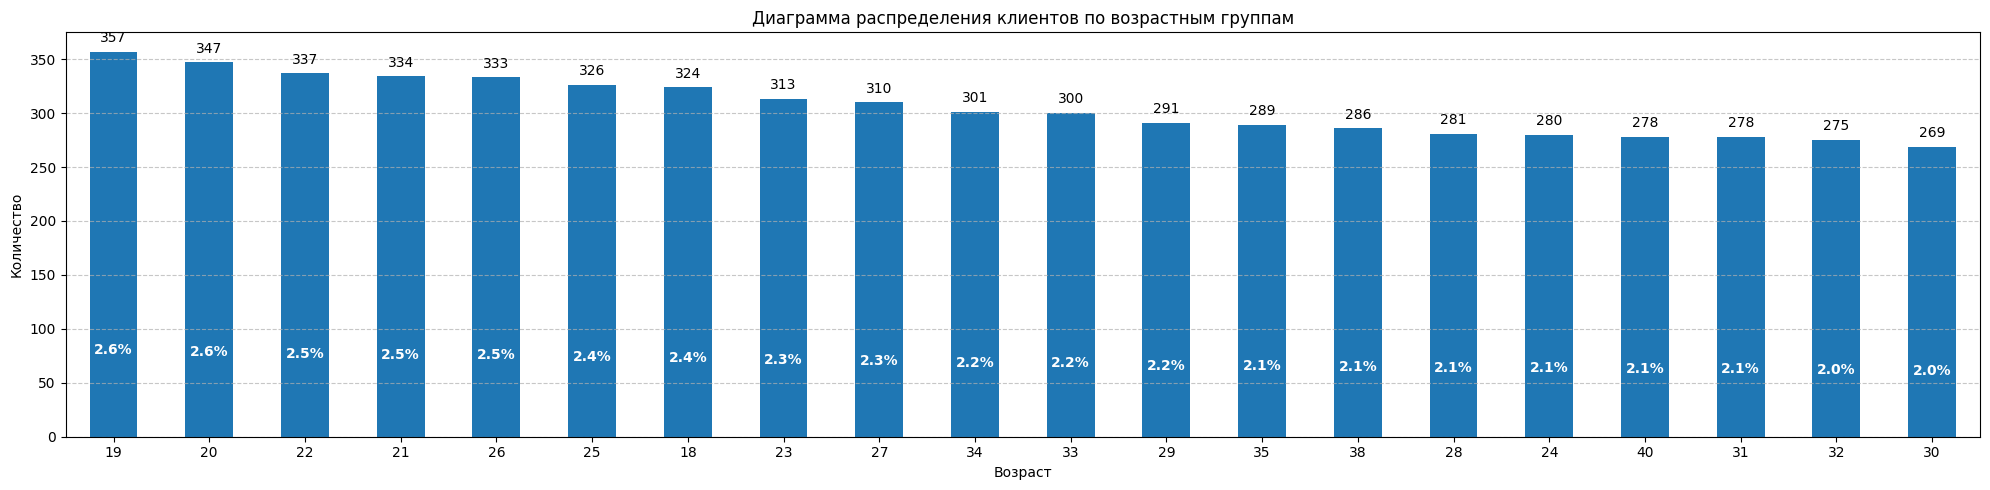

In [13]:
plot_bar_chart(df0_client_description['age'], xlabel='Возраст', title='Диаграмма распределения клиентов по возрастным группам', top_n=20, figsize=(20,5))

In [14]:
# Добавим признак возрастных групп
bins = [0, 25, 35, 45, 55, 120]
labels = ['young', 'early_career', 'peak_career', 'prime', 'senior']

df0_client_description['age_group'] = pd.cut(
    df0_client_description['age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

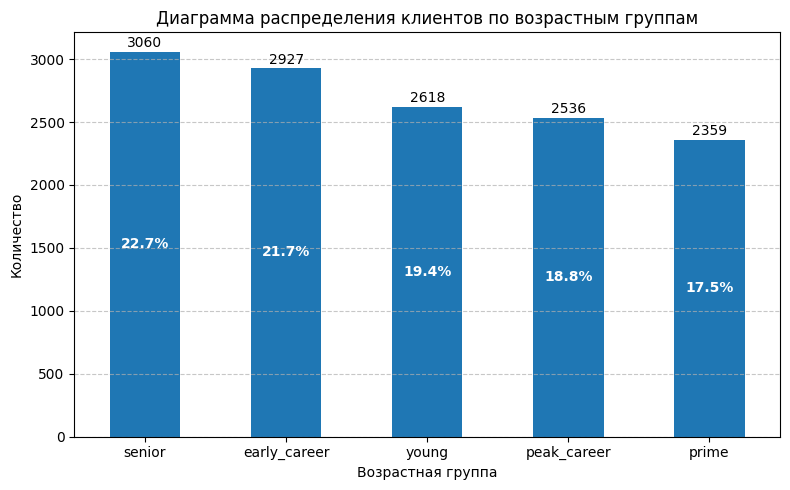

In [15]:
plot_bar_chart(df0_client_description['age_group'], xlabel='Возрастная группа', title='Диаграмма распределения клиентов по возрастным группам', figsize=(8,5))

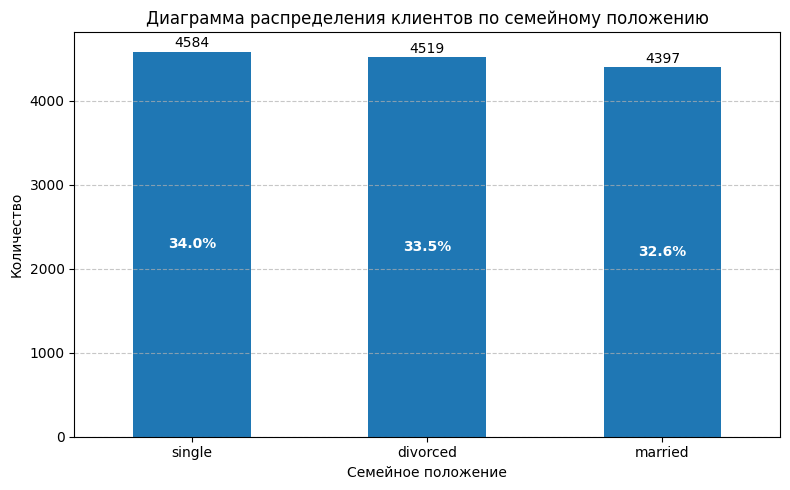

In [16]:
# Перевод значений категориальных признаков на английский
mapping = {
        'разведённые': 'divorced',
        'нет семьи': 'single',
        'есть семья': 'married'
    }
df0_client_description['marital_status'] = df0_client_description['marital_status'].map(mapping)

# Рисуем диаграмму bar chart
plot_bar_chart(df0_client_description['marital_status'], xlabel='Семейное положение', title='Диаграмма распределения клиентов по семейному положению', top_n=10, figsize=(8,5))

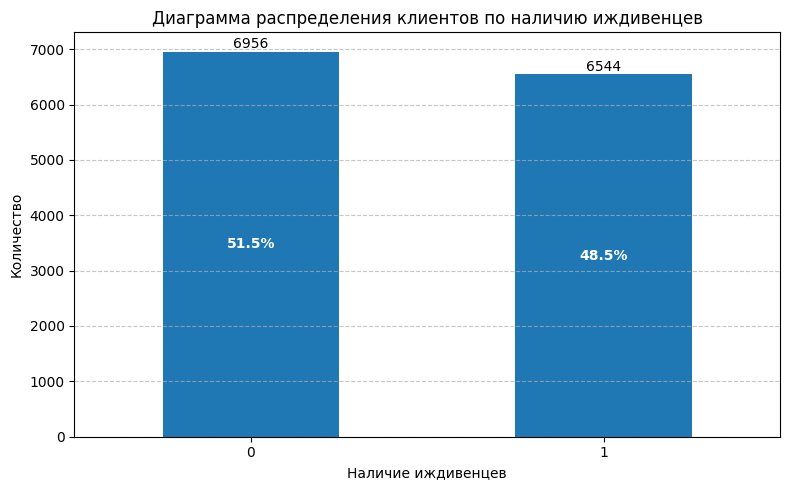

In [17]:
plot_bar_chart(df0_client_description['has_dependents'], xlabel='Наличие иждивенцев', title='Диаграмма распределения клиентов по наличию иждивенцев', top_n=10, figsize=(8,5))

### 3.6 Описание кредита: df0_credit_description

In [ ]:
df0_credit_description.info()

In [ ]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df0_credit_description.describe())

In [ ]:
histogram_chart(df=df0_credit_description, attr='monthly_income', bins=20, figsize=(8,5), title_text=f'Распределение клиентов по уровню доходу', ylabel='Количество')

In [ ]:
histogram_chart(df=df0_credit_description, attr='loan_amount', bins=20, figsize=(8,5), title_text=f'Распределение клиентов по сумме кредита', ylabel='Количество')

In [ ]:
boxplot_chart(df=df0_credit_description, feature_list=['monthly_income', 'loan_amount'], diagram_name='Диаграммы размаха по уровню дохода и сумме кредита')

### 3.7 Данные о наличии ипотеки: mortgage_presence

In [ ]:
df0_mortgage_presence.info()

In [ ]:
print('Первая дата периода:', df0_mortgage_presence['mortgage_open_date'].min())
print('последняя дата периода:', df0_mortgage_presence['mortgage_open_date'].max())

In [ ]:
df0_mortgage_presence['has_mortgage'].value_counts()

In [ ]:
plot_line_time_series(
    df=df0_mortgage_presence,
    date_col='mortgage_open_date',
    cat_cols=['has_mortgage'],
    title='Динамика открытия ипотечных кредитов',
    legend_title='Признак',
    ylabel='Количество клиентов с ипотекой'
    )

### 3.8 Данные о макроэкономических показателях России: macro_data

In [ ]:
df0_macro_data.info()

In [ ]:
plot_line_time_series(df=df0_macro_data, date_col='date', cat_cols=None, legend_title='Признаки', ylabel='Проценты')

###  Данные о дате проведения поведенческого скоринга: cohort_grid

In [ ]:
df0_cohort_grid.info()

In [ ]:
df0_cohort_grid.describe()

## Комментарий по итогам исследовательского анализа данных
---

## 4. Объединение таблиц: собираем все источники данных о клиентах в единую таблицу

### 4.1 Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

In [18]:
# =============================================================================================================================
# Поготовка единой матрицы объект - целевая переменная
# Объект моделирования — это клиент в конкретный месяц
# Целевая переменная — столбец, содержащий данные о том, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев
# =============================================================================================================================

# Шаг 1. Конвертируем все признаки с датами в формат datetime

# Таблица 1: просрочка платежа
df0_loan_payment_credit['overdue_start_date'] = pd.to_datetime(df0_loan_payment_credit['overdue_start_date'], format='%Y-%m-%d')
# Таблица 2: транзакции
df0_transactions['date'] = pd.to_datetime(df0_transactions['date'], format='%Y-%m-%d')
# Таблица 3: описание клиента
df0_client_description['registration_date'] = pd.to_datetime(df0_client_description['registration_date'], format='%Y-%m-%d')
# Таблица 5: ипотека
df0_mortgage_presence['mortgage_open_date'] = pd.to_datetime(df0_mortgage_presence['mortgage_open_date'], format='%Y-%m-%d')
# Таблица 6: кредитный рейтинг
df0_credit_rating['date'] = pd.to_datetime(df0_credit_rating['date'], format='%Y-%m-%d')
# Таблица 7: макроэкономические показатели
df0_macro_data['date'] = pd.to_datetime(df0_macro_data['date'], format='%Y-%m-%d')
# Таблица 8: скоринг
df0_cohort_grid['score_date'] = pd.to_datetime(df0_cohort_grid['score_date'], format='%Y-%m-%d')

# Шаг 2. Оставляем только первую дату просрочки (минимальную) для каждого id
# Согласно требованию выше: >Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.
df0_loan_payment_credit = df0_loan_payment_credit.loc[df0_loan_payment_credit.groupby('id')['overdue_start_date'].idxmin()].reset_index(drop=True)

In [35]:
# Шаг 3. Расчет целевой переменной default

# Исходный dataframe df0_cohort_grid
# Присоединяем df0_loan_payment_credit

# df0_credit_rating 
df1_union = pd.merge(
    left=df0_cohort_grid,
    right=df0_loan_payment_credit,
    how='left',
    on='id'
)

# Шаг 4. Определяем целевую переменную согласнов условия просрочка больше или равна 90 дней
# Дата начала периода в интервале [score_date, score_date + 365) 

df1_union['default'] = (
        df1_union['overdue_start_date'].between(
            df1_union['score_date'],
            df1_union['score_date'] + pd.Timedelta(days=365),
        inclusive='left'
    )
    &
    (
        df1_union['overdue_days'] >= 90
    )
).astype('int')


# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head(25)

,id,score_date,overdue_start_date,overdue_days,default
0,IDF55109846,2013-05-01,2014-12-01,120.0,0
1,IDF55109846,2013-06-01,2014-12-01,120.0,0
2,IDF55109846,2013-07-01,2014-12-01,120.0,0
3,IDF55109846,2013-08-01,2014-12-01,120.0,0
4,IDF55109846,2013-09-01,2014-12-01,120.0,0
5,IDF55109846,2013-10-01,2014-12-01,120.0,0
6,IDF55109846,2013-11-01,2014-12-01,120.0,0
7,IDF55109846,2013-12-01,2014-12-01,120.0,0
8,IDF55109846,2014-01-01,2014-12-01,120.0,1
9,IDF55109846,2014-02-01,2014-12-01,120.0,1


In [36]:
# Шаг 5. Удаляем строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`

mask_remove_past = (df1_union['overdue_start_date'] < df1_union['score_date']) & (df1_union['overdue_days'] >= 90)
df1_union = df1_union[~mask_remove_past].drop(columns=['overdue_start_date', 'overdue_days'])

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head(25)

,id,score_date,default
0,IDF55109846,2013-05-01,0
1,IDF55109846,2013-06-01,0
2,IDF55109846,2013-07-01,0
3,IDF55109846,2013-08-01,0
4,IDF55109846,2013-09-01,0
5,IDF55109846,2013-10-01,0
6,IDF55109846,2013-11-01,0
7,IDF55109846,2013-12-01,0
8,IDF55109846,2014-01-01,1
9,IDF55109846,2014-02-01,1


### 4.2 Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

In [37]:
# Шаг 6. Объединение INNER JOIN с таблицами с полным списком дат по составному ключу id - month

# Исходный dataframe df0_cohort_grid

# df0_credit_rating 
df1_union = pd.merge(
    left=df1_union,
    right=df0_credit_rating,
    how='inner',
    left_on=['id', 'score_date'],
    right_on=['id', 'date']
).drop(columns='date')

# df0_transactions
df1_union = pd.merge(
    left=df1_union,
    right=df0_transactions,
    how='inner',
    left_on=['id', 'score_date'],
    right_on=['id', 'date']
).drop(columns='date')

# Сортируем датасет по id клиента и по дате 
df1_union = df1_union.sort_values(by=['id', 'score_date'])

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,credit_score,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other
0,IDF55109846,2013-05-01,0,692,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,0,688,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,0,666,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,0,692,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,0,688,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


In [38]:

# Шаг 7. Не допускаем утечку данных: делаем сдвиг на 1 месяц
# Сдвигаем на 1 месяц значения кредитного рейтинга и потребительских расходов по категориям МСС 
# Список колонок для сдвига
init_cols = [
    'mcc_5300', 'mcc_5814', 'mcc_5812',
    'mcc_5411', 'mcc_3990', 'mcc_5722',
    'mcc_4900', 'mcc_other', 'credit_score'
]

# Создаем список с будущими колонками с лагом
lag_cols = []

# Сдвигаем на 1 месяц (лаг)
for col in init_cols:
    lag_name = f'{col}_lag_1m'
    df1_union[lag_name] = df1_union.groupby('id')[col].shift(1)
    lag_cols.append(lag_name)

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,credit_score,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m
0,IDF55109846,2013-05-01,0,692,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF55109846,2013-06-01,0,688,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0
2,IDF55109846,2013-07-01,0,666,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0
3,IDF55109846,2013-08-01,0,692,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0
4,IDF55109846,2013-09-01,0,688,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0


In [39]:
# Удаляем исходные признаки
df1_union = df1_union.drop(columns=init_cols) 

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m
0,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0
2,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0
3,IDF55109846,2013-08-01,0,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0
4,IDF55109846,2013-09-01,0,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0


In [40]:
# Шаг 8. Присоединяем LEFT JOIN df0_mortgage_presence с неполным списком дат по ключу id

# df0_mortgage_presence 
df1_union = pd.merge(
    left=df1_union,
    right=df0_mortgage_presence,
    how='left',
    on='id',
)

# Фильтруем: оставляем только строки, где ипотека открыта до скоринга
mask = df1_union['mortgage_open_date'] < df1_union['score_date']
df1_union.loc[~mask, 'has_mortgage'] = None
# Удаляем mortgage_open_date (так как более не нужна)
df1_union = df1_union.drop(columns='mortgage_open_date')

# Проверка на клиенте IDF54896351
df1_union[df1_union['id'] == 'IDF54896351'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage
0,IDF54896351,2013-03-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDF54896351,2013-04-01,0,2224.47,909.12,858.41,3911.52,428.480011,1464.28,2616.17,2161.25,656.0,1.0
2,IDF54896351,2013-05-01,0,1986.07,1729.86,857.94,3769.95,682.429993,1497.97,3011.24,2210.71,651.0,1.0
3,IDF54896351,2013-06-01,0,2120.91,2737.69,798.60,3436.64,720.280029,1389.35,2511.64,2145.21,678.0,1.0
4,IDF54896351,2013-07-01,0,2034.34,3429.41,930.14,3783.15,671.979980,1447.39,1864.56,2219.61,683.0,1.0


In [41]:
# Шаг 9. Присоединяем df0_macro_data по date
# # df0_macro_data 
df1_union = pd.merge(
    left=df1_union,
    right=df0_macro_data,
    how='left',
    left_on=['score_date'],
    right_on=['date']
).drop(columns='date')

# Сортируем датасет по id клиента и по дате 
df1_union = df1_union.sort_values(by=['id', 'score_date'])

# Список колонок для сдвига
init_cols = ['key_rate', 'unemployment_rate', 'inflation_rate']

# Создаем второй список с колонками с лагом
lag_cols_2 = []

# Сдвигаем на 1 месяц (лаг)
for col in init_cols:
    lag_name = f'{col}_lag_1m'
    df1_union[lag_name] = df1_union.groupby('id')[col].shift(1)
    lag_cols_2.append(lag_name)

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage,key_rate,unemployment_rate,inflation_rate,key_rate_lag_1m,unemployment_rate_lag_1m,inflation_rate_lag_1m
364760,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.5,5.4,0.66,NaN,NaN,NaN
364761,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0,NaN,5.5,5.3,0.42,5.5,5.4,0.66
364762,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0,NaN,5.5,5.3,0.82,5.5,5.3,0.42
364763,IDF55109846,2013-08-01,0,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0,NaN,5.5,5.2,0.14,5.5,5.3,0.82
364764,IDF55109846,2013-09-01,0,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0,NaN,5.5,5.1,0.21,5.5,5.2,0.14


In [42]:
# Удаляем исходные признаки
df1_union = df1_union.drop(columns=init_cols) 

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage,key_rate_lag_1m,unemployment_rate_lag_1m,inflation_rate_lag_1m
364760,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364761,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0,NaN,5.5,5.4,0.66
364762,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0,NaN,5.5,5.3,0.42
364763,IDF55109846,2013-08-01,0,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0,NaN,5.5,5.3,0.82
364764,IDF55109846,2013-09-01,0,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0,NaN,5.5,5.2,0.14


In [43]:
# Шаг 10. Присоединяем  df0_client_description и df0_credit_description по id клиента

# df0_client_description 
df1_union = pd.merge(
    left=df1_union,
    right=df0_client_description,
    how='left',
    on='id',
)

# df0_credit_description
df1_union = pd.merge(
    left=df1_union,
    right=df0_credit_description,
    how='left',
    on='id',
)

# Фильтруем: оставляем только строки, где регистрация клиента произошла до скоринга
mask = df1_union['registration_date'] < df1_union['score_date']
df1_union.loc[~mask, ['registration_date', 'age_group', 'age', 'marital_status', 'has_dependents']] = None
# Удаляем registration_date
df1_union = df1_union.drop(columns='registration_date')

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage,key_rate_lag_1m,unemployment_rate_lag_1m,inflation_rate_lag_1m,age,marital_status,has_dependents,age_group,monthly_income,loan_amount
364760,IDF55109846,2013-05-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27035,1960785
364761,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0,NaN,5.5,5.4,0.66,41.0,divorced,1.0,peak_career,27035,1960785
364762,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0,NaN,5.5,5.3,0.42,41.0,divorced,1.0,peak_career,27035,1960785
364763,IDF55109846,2013-08-01,0,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0,NaN,5.5,5.3,0.82,41.0,divorced,1.0,peak_career,27035,1960785
364764,IDF55109846,2013-09-01,0,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0,NaN,5.5,5.2,0.14,41.0,divorced,1.0,peak_career,27035,1960785


In [44]:
# Удаляем строки, где есть хотя бы один NaN среди лагов
rows_before = len(df1_union)
df1_union = df1_union.dropna(subset=lag_cols + lag_cols_2)

# Считаем, сколько потеряли
rows_after = len(df1_union)
print(f"Удалено строк: {rows_before - rows_after} ({(rows_before - rows_after)/rows_before:.2%})")

Удалено строк: 13500 (3.08%)


In [45]:
# Заполняем пустые значения по отсутсвию ипотеки
df1_union['has_mortgage'] = df1_union['has_mortgage'].fillna(0)

# Приводим типы данных
df1_union['has_mortgage'] = df1_union['has_mortgage'].astype('int8')
df1_union['has_dependents'] = df1_union['has_dependents'].astype('int8')

# Проверка на клиенте IDF55109846
df1_union[df1_union['id'] == 'IDF55109846'].head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage,key_rate_lag_1m,unemployment_rate_lag_1m,inflation_rate_lag_1m,age,marital_status,has_dependents,age_group,monthly_income,loan_amount
364761,IDF55109846,2013-06-01,0,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35,692.0,0,5.5,5.4,0.66,41.0,divorced,1,peak_career,27035,1960785
364762,IDF55109846,2013-07-01,0,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61,688.0,0,5.5,5.3,0.42,41.0,divorced,1,peak_career,27035,1960785
364763,IDF55109846,2013-08-01,0,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06,666.0,0,5.5,5.3,0.82,41.0,divorced,1,peak_career,27035,1960785
364764,IDF55109846,2013-09-01,0,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44,692.0,0,5.5,5.2,0.14,41.0,divorced,1,peak_career,27035,1960785
364765,IDF55109846,2013-10-01,0,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90,688.0,0,5.5,5.1,0.21,41.0,divorced,1,peak_career,27035,1960785


In [46]:
# Датасет матрицы "объект-целевая переменная" готов
df1_union.info()

<class 'pandas.DataFrame'>
Index: 424879 entries, 1 to 438378
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id                        424879 non-null  str           
 1   score_date                424879 non-null  datetime64[us]
 2   default                   424879 non-null  int64         
 3   mcc_5300_lag_1m           424879 non-null  float64       
 4   mcc_5814_lag_1m           424879 non-null  float64       
 5   mcc_5812_lag_1m           424879 non-null  float64       
 6   mcc_5411_lag_1m           424879 non-null  float64       
 7   mcc_3990_lag_1m           424879 non-null  float32       
 8   mcc_5722_lag_1m           424879 non-null  float64       
 9   mcc_4900_lag_1m           424879 non-null  float64       
 10  mcc_other_lag_1m          424879 non-null  float64       
 11  credit_score_lag_1m       424879 non-null  float64       
 12  has_mortgage      

## Сделайте выводы о получившейся таблице
---

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [47]:
def add_mcc_rolling_and_momentum(df, lag_cols, windows=[3, 6, 12], group_col='id', date_col='score_date'):
    """
    lag_cols: список колонок, которые уже являются лагами (например, mcc_5300_lag_1m)
    Для каждого окна строит:
      - roll_mean
      - momentum_<window>m = lag / roll_mean (если roll_mean > 0, иначе 0)
    
    Возвращает новый DataFrame
    """
    # Делаем копию и сортируем — это обязательно для корректного rolling
    df_out = df.sort_values([group_col, date_col]).copy()
    
    for col in lag_cols:
        s = df_out[col]
        g = s.groupby(df_out[group_col])
        
        for w in windows:
            # Скользящее среднее по окну w
            roll_mean = g.rolling(window=w, min_periods=1).mean().droplevel(0)
            
            # Momentum: текущий лаг / среднее за w месяцев
            # Защита от деления на ноль: где roll_mean == 0, ставим 0
            with np.errstate(divide='ignore', invalid='ignore'):
                momentum = s / roll_mean
                momentum = momentum.replace([np.inf, -np.inf], np.nan)
                momentum = momentum.fillna(0.0)  # или оставь NaN, если будешь импутировать позже
            
            # Сохраняем признаки
            df_out[f'{col}_roll_mean_{w}m'] = roll_mean
            df_out[f'{col}_momentum_{w}m'] = momentum
            
    return df_out


In [48]:
# Берем только колонки с лагами по MCC
mcc_lag_cols = [col for col in df1_union.columns if col.startswith('mcc_') and col.endswith('_lag_1m')]

df1_union = add_mcc_rolling_and_momentum(df=df1_union, lag_cols=mcc_lag_cols, windows=[3, 6])

# Добавляем признаки сезонности и тренда
df1_union['month_sin'] = np.sin(2 * np.pi * df1_union['score_date'].dt.month / 12)
df1_union['month_cos'] = np.cos(2 * np.pi * df1_union['score_date'].dt.month / 12)

# Добавляем Debt-to-income ratio
df1_union['debt_to_income_ratio'] = df1_union['loan_amount'] / df1_union['monthly_income']

df1_union.info()

<class 'pandas.DataFrame'>
Index: 424879 entries, 1 to 438378
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             424879 non-null  str           
 1   score_date                     424879 non-null  datetime64[us]
 2   default                        424879 non-null  int64         
 3   mcc_5300_lag_1m                424879 non-null  float64       
 4   mcc_5814_lag_1m                424879 non-null  float64       
 5   mcc_5812_lag_1m                424879 non-null  float64       
 6   mcc_5411_lag_1m                424879 non-null  float64       
 7   mcc_3990_lag_1m                424879 non-null  float32       
 8   mcc_5722_lag_1m                424879 non-null  float64       
 9   mcc_4900_lag_1m                424879 non-null  float64       
 10  mcc_other_lag_1m               424879 non-null  float64       
 11  credit_score_lag

In [52]:
df1_union.head()

,id,score_date,default,mcc_5300_lag_1m,mcc_5814_lag_1m,mcc_5812_lag_1m,mcc_5411_lag_1m,mcc_3990_lag_1m,mcc_5722_lag_1m,mcc_4900_lag_1m,mcc_other_lag_1m,credit_score_lag_1m,has_mortgage,key_rate_lag_1m,unemployment_rate_lag_1m,inflation_rate_lag_1m,age,marital_status,has_dependents,age_group,monthly_income,loan_amount,mcc_5300_lag_1m_roll_mean_3m,mcc_5300_lag_1m_momentum_3m,mcc_5300_lag_1m_roll_mean_6m,mcc_5300_lag_1m_momentum_6m,mcc_5814_lag_1m_roll_mean_3m,mcc_5814_lag_1m_momentum_3m,mcc_5814_lag_1m_roll_mean_6m,mcc_5814_lag_1m_momentum_6m,mcc_5812_lag_1m_roll_mean_3m,mcc_5812_lag_1m_momentum_3m,mcc_5812_lag_1m_roll_mean_6m,mcc_5812_lag_1m_momentum_6m,mcc_5411_lag_1m_roll_mean_3m,mcc_5411_lag_1m_momentum_3m,mcc_5411_lag_1m_roll_mean_6m,mcc_5411_lag_1m_momentum_6m,mcc_3990_lag_1m_roll_mean_3m,mcc_3990_lag_1m_momentum_3m,mcc_3990_lag_1m_roll_mean_6m,mcc_3990_lag_1m_momentum_6m,mcc_5722_lag_1m_roll_mean_3m,mcc_5722_lag_1m_momentum_3m,mcc_5722_lag_1m_roll_mean_6m,mcc_5722_lag_1m_momentum_6m,mcc_4900_lag_1m_roll_mean_3m,mcc_4900_lag_1m_momentum_3m,mcc_4900_lag_1m_roll_mean_6m,mcc_4900_lag_1m_momentum_6m,mcc_other_lag_1m_roll_mean_3m,mcc_other_lag_1m_momentum_3m,mcc_other_lag_1m_roll_mean_6m,mcc_other_lag_1m_momentum_6m,month_sin,month_cos,debt_to_income_ratio
1,IDF54896351,2013-04-01,0,2224.47,909.12,858.41,3911.52,428.480011,1464.28,2616.17,2161.25,656.0,1,5.5,5.9,0.34,39.0,single,1,peak_career,17633,2506575,2224.470000,1.000000,2224.470000,1.000000,909.120000,1.000000,909.120000,1.000000,858.410000,1.000000,858.410000,1.000000,3911.520000,1.000000,3911.520000,1.000000,428.480011,1.000000,428.480011,1.000000,1464.280000,1.000000,1464.280000,1.000000,2616.170000,1.000000,2616.170000,1.000000,2161.250000,1.000000,2161.250,1.000000,8.660254e-01,-0.500000,142.152498
2,IDF54896351,2013-05-01,0,1986.07,1729.86,857.94,3769.95,682.429993,1497.97,3011.24,2210.71,651.0,1,5.5,5.5,0.51,39.0,single,1,peak_career,17633,2506575,2105.270000,0.943380,2105.270000,0.943380,1319.490000,1.311007,1319.490000,1.311007,858.175000,0.999726,858.175000,0.999726,3840.735000,0.981570,3840.735000,0.981570,555.455002,1.228596,555.455002,1.228596,1481.125000,1.011373,1481.125000,1.011373,2813.705000,1.070205,2813.705000,1.070205,2185.980000,1.011313,2185.980,1.011313,5.000000e-01,-0.866025,142.152498
3,IDF54896351,2013-06-01,0,2120.91,2737.69,798.60,3436.64,720.280029,1389.35,2511.64,2145.21,678.0,1,5.5,5.4,0.66,39.0,single,1,peak_career,17633,2506575,2110.483333,1.004940,2110.483333,1.004940,1792.223333,1.527538,1792.223333,1.527538,838.316667,0.952623,838.316667,0.952623,3706.036667,0.927309,3706.036667,0.927309,610.396678,1.180020,610.396678,1.180020,1450.533333,0.957820,1450.533333,0.957820,2713.016667,0.925774,2713.016667,0.925774,2172.390000,0.987488,2172.390,0.987488,1.224647e-16,-1.000000,142.152498
4,IDF54896351,2013-07-01,0,2034.34,3429.41,930.14,3783.15,671.979980,1447.39,1864.56,2219.61,683.0,1,5.5,5.3,0.42,39.0,single,1,peak_career,17633,2506575,2047.106667,0.993764,2091.447500,0.972695,2632.320000,1.302809,2201.520000,1.557746,862.226667,1.078765,861.272500,1.079960,3663.246667,1.032731,3725.315000,1.015525,691.563334,0.971682,625.792503,1.073806,1444.903333,1.001721,1449.747500,0.998374,2462.480000,0.757188,2500.902500,0.745555,2191.843333,1.012668,2184.195,1.016214,-5.000000e-01,-0.866025,142.152498
5,IDF54896351,2013-08-01,0,2099.40,2852.99,906.69,3635.57,425.579987,1487.86,1148.91,2819.64,679.0,1,5.5,5.3,0.82,39.0,single,1,peak_career,17633,2506575,2084.883333,1.006963,2093.038000,1.003040,3006.696667,0.948879,2331.814000,1.223507,878.476667,1.032116,870.356000,1.041746,3618.453333,1.004730,3707.366000,0.980634,605.946665,0.702339,585.750000,0.726556,1441.533333,1.032137,1457.370000,1.020921,1841.703333,0.623830,2230.504000,0.515090,2394.820000,1.177391,2311.284,1.219945,-8.660254e-01,-0.500000,142.152498


## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.

